# Pandas Practice: The Iris Dataset

In this notebook you will independently apply everything from `01_Introduction_to_Pandas.ipynb` and `03_Introduction_to_Visualization.ipynb` to a new dataset. The **Iris dataset** is one of the most widely used datasets in data science, it contains measurements (in centimetres) of 150 iris flowers across three species. Your goal is to load it, explore it, answer questions with code, and visualise your findings.

---

![Iris species](../assets/iris.png)

---

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part 1: Exploring the Data

### Challenge 1: Preview and inspect

Display the first 5 rows and the last 10 rows of the DataFrame.

In [3]:
# YOUR CODE HERE
display(df.head(5))
display(df.tail(10))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Challenge 2: How many irises are in the dataset?

How many rows and columns does the DataFrame have?

In [5]:
# YOUR CODE HERE
df.shape

(150, 5)

### Challenge 3: How many species are there?

Find out how many distinct species exist in the dataset, and what they are called.

In [6]:
# YOUR CODE HERE
names = df["species"].unique()
display(names)

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

---

## Part 2: Statistics

### Challenge 4: Descriptive statistics for petal length

Calculate the mean, median, and mode for `petal_length`. What can you conclude about the distribution?

Mean: 3.758666666666666
Median: 4.35
Mode: 1.5


<Axes: xlabel='Petal Length', ylabel='Count'>

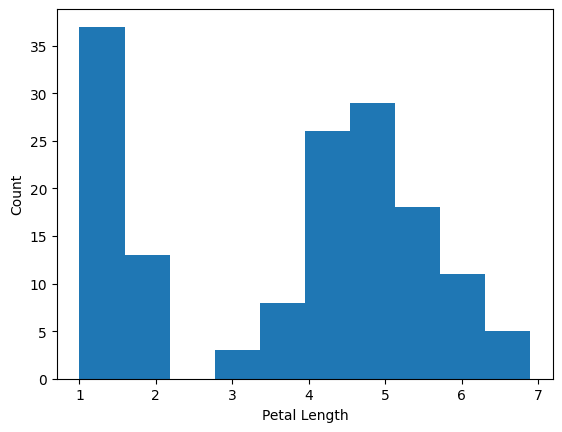

In [15]:
# YOUR CODE HERE
mean = df["petal_length"].mean()
print(f"Mean: {mean}")

median = df["petal_length"].median()
print(f"Median: {median}")

mode = df["petal_length"].mode()[0]
print(f"Mode: {mode}")

df["petal_length"].plot(kind = "hist",
        xlabel = "Petal Length",
        ylabel = "Count",)



### Challenge 5: Range and spread

What is the smallest and largest value for `petal_length`? Calculate the variance and standard deviation.

In [18]:
# YOUR CODE HERE
smallest = df["petal_length"].min()
print(f"Smallest: {round(smallest, 3)} [cm]")
largest = df["petal_length"].max()
print(f"Largest: {round(largest, 3)} [cm]")
std = df["petal_length"].std()
print(f"Standard Deviation: {round(std, 3)} [cm]")
var = df["petal_length"].var()
print(f"Variance: {round(var, 3)} [cm]")


Smallest: 1.0 [cm]
Largest: 6.9 [cm]
Standard Deviation: 1.764 [cm]
Variance: 3.113 [cm]


### Challenge 6: Full summary

Use a single command to get the basic descriptive statistics for all columns.

In [20]:
# YOUR CODE HERE
df.describe(include = "all")


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


### Challenge 7: Overall average sepal length

What is the average `sepal_length` across all 150 flowers?

In [21]:
# YOUR CODE HERE
ave_sepal_length = df["sepal_length"].mean()
print(f"Average Sepal Length: {round(ave_sepal_length, 3)} [cm]")


Average Sepal Length: 5.843 [cm]


---

## Part 3: Groupby

### Challenge 8: Count by species

Use `groupby` to count the number of observations for each species.

In [23]:
count_by_species= df.groupby("species")
display(count_by_species.size())
# YOUR CODE HERE

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

### Challenge 9: Average measurements by species

Use `groupby` to find the average `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` for each species.

In [28]:
# YOUR CODE HERE
sepal_length_by_species = df.groupby("species")["sepal_length"].mean()
for i in sepal_length_by_species.index:
    print(f"Average Sepal Length for {i}: {round(sepal_length_by_species[i], 3)} [cm]")
print("")

sepal_width_by_species = df.groupby("species")["sepal_width"].mean()
for i in sepal_width_by_species.index:
    print(f"Average Sepal Width for {i}: {round(sepal_width_by_species[i], 3)} [cm]")
print("")


petal_length_by_species = df.groupby("species")["petal_length"].mean()
for i in petal_length_by_species.index:
    print(f"Average Petal Length for {i}: {round(petal_length_by_species[i], 3)} [cm]")
print("")


petal_width_by_species = df.groupby("species")["petal_width"].mean()
for i in petal_width_by_species.index:
    print(f"Average Petal Width for {i}: {round(petal_width_by_species[i], 3)} [cm]")
print("")


Average Sepal Length for Iris-setosa: 5.006 [cm]
Average Sepal Length for Iris-versicolor: 5.936 [cm]
Average Sepal Length for Iris-virginica: 6.588 [cm]

Average Sepal Width for Iris-setosa: 3.418 [cm]
Average Sepal Width for Iris-versicolor: 2.77 [cm]
Average Sepal Width for Iris-virginica: 2.974 [cm]

Average Petal Length for Iris-setosa: 1.464 [cm]
Average Petal Length for Iris-versicolor: 4.26 [cm]
Average Petal Length for Iris-virginica: 5.552 [cm]

Average Petal Width for Iris-setosa: 0.244 [cm]
Average Petal Width for Iris-versicolor: 1.326 [cm]
Average Petal Width for Iris-virginica: 2.026 [cm]



---

## Part 4: Column Operations and Filtering

### Challenge 10: Add a new column

Create a new column `sepal_total` that is the sum of `sepal_width` and `sepal_length`.

In [29]:
# YOUR CODE HERE
df["sepal total"] = df["sepal_length"] + df["sepal_width"]
df.head(5)


,sepal_length,sepal_width,petal_length,petal_width,species,sepal total
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


### Challenge 11: Add petal area

Create a new column `petal_area` as a rough estimate of petal area: `petal_length × petal_width`.

In [30]:
# YOUR CODE HERE
df["petal_area"] = df["petal_length"] * df["petal_width"]
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species,sepal total,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


### Challenge 12: Filter by petal area

Create a new DataFrame containing only the flowers where `petal_area` is greater than 1 cm².

In [31]:
# YOUR CODE HERE
area_filter = df["petal_area"] >= 1
df_filtered = df[area_filter]  
df_filtered.head(5) 

,sepal_length,sepal_width,petal_length,petal_width,species,sepal total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


### Challenge 13: Split by species

Create three separate DataFrames, one for each species, using the full dataset.

In [36]:
# YOUR CODE HERE
unique_species = df["species"].unique()
dfs = {}
for species in unique_species:
    dfs[species] = df[df["species"] == species]
    
display(dfs["Iris-setosa"].head(5))
display(dfs["Iris-versicolor"].head(5))
display(dfs["Iris-virginica"].head(5))


,sepal_length,sepal_width,petal_length,petal_width,species,sepal total,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


,sepal_length,sepal_width,petal_length,petal_width,species,sepal total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


,sepal_length,sepal_width,petal_length,petal_width,species,sepal total,petal_area
100,6.3,3.3,6.0,2.5,Iris-virginica,9.6,15.00
101,5.8,2.7,5.1,1.9,Iris-virginica,8.5,9.69
102,7.1,3.0,5.9,2.1,Iris-virginica,10.1,12.39
103,6.3,2.9,5.6,1.8,Iris-virginica,9.2,10.08
104,6.5,3.0,5.8,2.2,Iris-virginica,9.5,12.76


---

## Part 5: Visualisation

### Challenge 14: Histogram of petal length

Create a histogram of `petal_length`. Describe the distribution, is it symmetric, skewed, or does it appear to have multiple peaks?

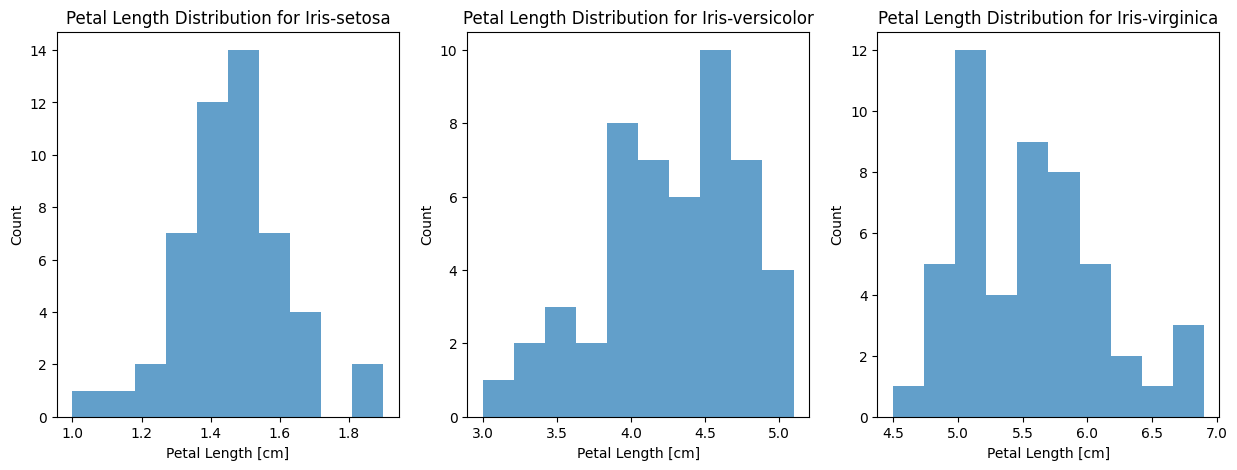

In [37]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, species in enumerate(unique_species):
    axs[i].hist(dfs[species]["petal_length"], bins=10, alpha=0.7)
    axs[i].set_title(f"Petal Length Distribution for {species}")
    axs[i].set_xlabel("Petal Length [cm]")
    axs[i].set_ylabel("Count")


### Challenge 15: Scatter matrix of petal dimensions

Create a scatter plot of `petal_length` vs `petal_width`. Do larger petals tend to be longer as well?

> Bonus: use `pd.plotting.scatter_matrix(df)` to see all pairwise relationships at once.

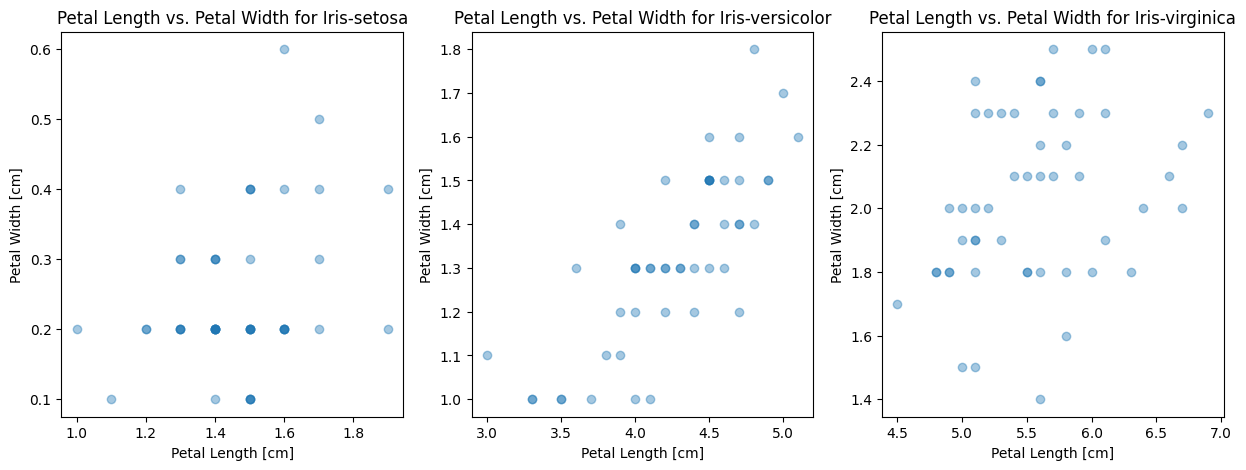

In [40]:
# YOUR CODE HERE
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, species in enumerate(unique_species):
    axs[i].scatter(
        x = dfs[species]["petal_length"],
        y = dfs[species]["petal_width"],
        alpha=0.4)

    axs[i].set_title(f"Petal Length vs. Petal Width for {species}")
    axs[i].set_xlabel("Petal Length [cm]")
    axs[i].set_ylabel("Petal Width [cm]")